In [1]:
import pandas as pd
data = pd.read_csv(r"C:\Users\aruna\Downloads\creditcard.csv\creditcard.csv")
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [14]:
import warnings
warnings.filterwarnings("ignore")

In [9]:
import sys
!{sys.executable} -m pip install bayesian-optimization

  Using cached bayesian_optimization-3.2.1-py3-none-any.whl.metadata (11 kB)
Using cached bayesian_optimization-3.2.1-py3-none-any.whl (37 kB)


In [2]:
#removing duplicates

print("Before removing duplicates: ",data.shape[0])
data.drop_duplicates(inplace=True)
data.reset_index(drop=True,inplace=True)
print("After removing duplicates: ",data.shape[0])

Before removing duplicates:  284807
After removing duplicates:  283726


In [3]:
from sklearn.model_selection import train_test_split

X = data.drop('Class', axis=1)
y = data['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [4]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif

selector = SelectKBest(score_func=mutual_info_classif, k=6)

X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)


selected_features = X_train.columns[selector.get_support()]
print("Selected features:", selected_features)

X_train = X_train[selected_features]
X_test = X_test[selected_features]

Selected features: Index(['V10', 'V11', 'V12', 'V14', 'V16', 'V17'], dtype='object')


In [5]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=selected_features,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=selected_features,
    index=X_test.index
)

In [18]:
import time
import numpy as np
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from bayes_opt import BayesianOptimization
import warnings
warnings.filterwarnings("ignore")
# Purpose function for Bayesian optimization
def lgbm_cv(learning_rate, max_depth, num_leaves):
    model = LGBMClassifier(
        learning_rate=learning_rate,
        num_leaves=int(round(num_leaves)),
        max_depth=int(round(max_depth)),
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring='neg_log_loss')
    return np.mean(scores['test_score'])

# Parameter search space
params = {
    'learning_rate': (0.001, 0.2),
    'max_depth': (3, 15),       # removed -1, set a realistic range
    'num_leaves': (2, 250)
}

# Bayesian Optimization
lgbmBO = BayesianOptimization(f=lgbm_cv, pbounds=params, random_state=42)

start = time.time()
lgbmBO.maximize(init_points=5, n_iter=8)

print('It takes %.2f minutes' % ((time.time() - start)/60))

# Best parameters
params_lgbm = lgbmBO.max['params']
params_lgbm['max_depth'] = round(params_lgbm['max_depth'])
params_lgbm['num_leaves'] = round(params_lgbm['num_leaves'])
print(params_lgbm)


|   iter    |  target   | learni... | max_depth | num_le... |
-------------------------------------------------------------
| 1         | -0.004515 | 0.0755334 | 14.408571 | 183.53449 |
| 2         | -0.015354 | 0.1201330 | 4.8722236 | 40.686641 |
| 3         | -0.160346 | 0.0125586 | 13.394113 | 151.07652 |
| 4         | -0.044532 | 0.1419064 | 3.2470139 | 242.53764 |
| 5         | -0.005457 | 0.1666560 | 5.5480693 | 47.092591 |
| 6         | -0.004729 | 0.0918361 | 15.0      | 205.55538 |
| 7         | -0.006090 | 0.1731444 | 14.999509 | 77.759035 |
| 8         | -0.005699 | 0.1443883 | 13.274570 | 182.26408 |
| 9         | -0.117442 | 0.2       | 15.0      | 2.0       |
| 10        | -0.620176 | 0.001     | 3.0       | 98.889854 |
| 11        | -0.605181 | 0.001     | 15.0      | 62.236233 |
| 12        | -0.004859 | 0.2       | 6.6895182 | 194.62978 |
| 13        | -0.029014 | 0.2       | 3.0       | 210.39940 |
It takes 2.25 minutes
{'learning_rate': np.float64(0.07553348365062514

In [27]:
import time
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from bayes_opt import BayesianOptimization
import warnings
warnings.filterwarnings("ignore")

# Purpose function for Bayesian optimization
def xgb_cv(learning_rate, max_depth, n_estimators):
    model = XGBClassifier(
        learning_rate=learning_rate,
        max_depth=int(round(max_depth)),
        n_estimators=int(round(n_estimators)),
        scale_pos_weight=592,   # adjust for imbalance
        random_state=42,
        n_jobs=-1,
        verbosity=0             # suppress warnings/logs
    )
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring='neg_log_loss')
    return np.mean(scores['test_score'])

# Parameter search space
params = {
    'learning_rate': (0.001, 0.2),
    'max_depth': (3, 10),
    'n_estimators': (50, 100)
}

# Bayesian Optimization
xgbBO = BayesianOptimization(f=xgb_cv, pbounds=params, random_state=42)

start = time.time()
xgbBO.maximize(init_points=5, n_iter=8)

print('It takes %.2f minutes' % ((time.time() - start)/60))

# Best parameters
params_xgb = xgbBO.max['params']
params_xgb['max_depth'] = round(params_xgb['max_depth'])
params_xgb['n_estimators'] = round(params_xgb['n_estimators'])
params_xgb['learning_rate'] = round(params_xgb['learning_rate'], 4)
print(params_xgb)


|   iter    |  target   | learni... | max_depth | n_esti... |
-------------------------------------------------------------
| 1         | -0.005186 | 0.0755334 | 9.6550001 | 86.599697 |
| 2         | -0.057355 | 0.1201330 | 4.0921304 | 57.799726 |
| 3         | -0.216797 | 0.0125586 | 9.0632330 | 80.055750 |
| 4         | -0.045181 | 0.1419064 | 3.1440914 | 98.495492 |
| 5         | -0.037795 | 0.1666560 | 4.4863737 | 59.091248 |
| 6         | -0.004748 | 0.1076619 | 9.4787432 | 90.243901 |
| 7         | -0.618377 | 0.001     | 4.5517235 | 89.108000 |
| 8         | -0.004827 | 0.2       | 10.0      | 94.160259 |
| 9         | -0.004732 | 0.2       | 8.4272817 | 98.700138 |
| 10        | -0.633651 | 0.001     | 10.0      | 59.349640 |
| 11        | -0.049024 | 0.2       | 3.0       | 63.876638 |
| 12        | -0.044944 | 0.2       | 3.0       | 69.704884 |
| 13        | -0.004704 | 0.2       | 8.1791424 | 70.326034 |
It takes 1.02 minutes
{'learning_rate': np.float64(0.2), 'max_depth': 

In [28]:
import time
import numpy as np
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss
from bayes_opt import BayesianOptimization
import warnings
warnings.filterwarnings("ignore")

def cat_cv(learning_rate, depth, iterations):
    learning_rate = float(learning_rate)
    depth = int(round(depth))
    iterations = int(round(iterations))

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []

    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = CatBoostClassifier(
            learning_rate=learning_rate,
            depth=depth,
            iterations=iterations,
            class_weights=[1, 592],   # ✅ works fine now
            verbose=0,
            random_state=42
        )

        model.fit(X_tr, y_tr)
        y_pred = model.predict_proba(X_val)[:, 1]

        score = -log_loss(y_val, y_pred)   # maximize
        scores.append(score)

    return np.mean(scores)

params = {
    'learning_rate': (0.01, 0.2),
    'depth': (6, 12),
    'iterations': (100, 300)
}

catBO = BayesianOptimization(
    f=cat_cv,
    pbounds=params,
    random_state=42,
    verbose=2
)

start = time.time()

catBO.maximize(
    init_points=4,
    n_iter=10
)

print('Time: %.2f minutes' % ((time.time() - start)/60))

params_cat = catBO.max['params']
params_cat['depth'] = int(round(params_cat['depth']))
params_cat['iterations'] = int(round(params_cat['iterations']))
params_cat['learning_rate'] = float(round(params_cat['learning_rate'], 4))

print("Best Params:", params_cat)

|   iter    |  target   | learni... |   depth   | iterat... |
-------------------------------------------------------------
| 1         | -0.004879 | 0.0811626 | 11.704285 | 246.39878 |
| 2         | -0.017361 | 0.1237451 | 6.9361118 | 131.19890 |
| 3         | -0.007708 | 0.0210358 | 11.197056 | 220.22300 |
| 4         | -0.006061 | 0.1445337 | 6.1235069 | 293.98197 |
| 5         | -0.004874 | 0.0622687 | 11.520005 | 247.82090 |
| 6         | -0.005860 | 0.1808674 | 6.0       | 244.92724 |
| 7         | -0.005000 | 0.2       | 12.0      | 274.29355 |
| 8         | -0.005000 | 0.2       | 12.0      | 300.0     |
| 9         | -0.005000 | 0.2       | 12.0      | 261.02411 |
| 10        | -0.010534 | 0.01      | 12.0      | 288.56036 |
| 11        | -0.082640 | 0.0282543 | 6.1877258 | 184.68411 |
| 12        | -0.264451 | 0.01      | 12.0      | 100.0     |
| 13        | -0.005835 | 0.2       | 12.0      | 151.20257 |
| 14        | -0.222278 | 0.01      | 6.0       | 144.19808 |
Time: 32

In [30]:
import lightgbm as lgb
import joblib
best_params = {
    'objective': 'binary',
    'learning_rate': 0.07553348365062514,
    'num_leaves': 184,
    'max_depth': 14,
    'class_weight': 'balanced',
    'random_state': 42
}

model = lgb.LGBMClassifier(**best_params)

model.fit(X_train, y_train)

# save model
joblib.dump(model, "lgbm_model.pkl")

['lgbm_model.pkl']

In [33]:
import xgboost as xgb
import joblib
#{'learning_rate': np.float64(0.2), 'max_depth': 8, 'n_estimators': 70}
# your optimized params (example)
best_params = {
    'objective': 'binary:logistic',
    'learning_rate': 0.2,
    'max_depth': 8,
    'n_estimators': 70,
    'scale_pos_weight': 598.8435517970402,  # IMPORTANT for your imbalance
    'random_state': 42,
    'eval_metric': 'logloss'
}

model = xgb.XGBClassifier(**best_params)

model.fit(X_train, y_train)

# save model
joblib.dump(model, "xgb_model.pkl")

['xgb_model.pkl']

In [34]:
from catboost import CatBoostClassifier
import joblib
#Best Params: {'learning_rate': 0.0623, 'depth': 12, 'iterations': 248}
# your optimized params (example)
best_params = {
    'iterations': 248,
    'learning_rate': 0.0623,
    'depth': 12,
    'loss_function': 'Logloss',
    'eval_metric': 'Logloss',
    'random_seed': 42,
    'verbose': 0,
    'class_weights': [1, 599]  # IMPORTANT for imbalance (class 0, class 1)
}

model = CatBoostClassifier(**best_params)

model.fit(X_train, y_train)

# save model
joblib.dump(model, "catboost_model.pkl")

['catboost_model.pkl']

In [35]:
from sklearn.linear_model import LogisticRegression
import joblib

# your params
model = LogisticRegression(
    class_weight='balanced',   # IMPORTANT for imbalance
    max_iter=1000,
    random_state=42,
    solver='lbfgs'
)

model.fit(X_train, y_train)

# save model
joblib.dump(model, "logreg_model.pkl")

['logreg_model.pkl']

In [ ]:
'''
import joblib

model = joblib.load("xgb_model.pkl")
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]
'''

In [38]:
logreg_model= joblib.load("logreg_model.pkl")
logreg_pred= logreg_model.predict(X_test)
logreg_proba=logreg_model.predict_proba(X_test)[:,1]

lgbm_model=joblib.load("lgbm_model.pkl")
lgbm_pred=lgbm_model.predict(X_test)
lgbm_proba=lgbm_model.predict_proba(X_test)[:,1]

xgb_model = joblib.load("xgb_model.pkl")
xgb_pred = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

cat_model = joblib.load("catboost_model.pkl")
cat_pred = cat_model.predict(X_test)
cat_proba = cat_model.predict_proba(X_test)[:, 1]

In [39]:
import numpy as np

def soft_vote_2(model1, model2, X, threshold=0.5, w1=1, w2=1):
    p1 = model1.predict_proba(X)[:, 1]
    p2 = model2.predict_proba(X)[:, 1]
    
    # weighted average
    prob = (w1 * p1 + w2 * p2) / (w1 + w2)
    
    pred = (prob >= threshold).astype(int)
    return pred, prob

import numpy as np

def soft_vote_3(model1, model2, model3, X, threshold=0.5, w1=1, w2=1, w3=1):
    p1 = model1.predict_proba(X)[:, 1]
    p2 = model2.predict_proba(X)[:, 1]
    p3 = model3.predict_proba(X)[:, 1]
    
    # weighted average
    prob = (w1 * p1 + w2 * p2 + w3 * p3) / (w1 + w2 + w3)
    
    pred = (prob >= threshold).astype(int)
    return pred, prob

In [41]:
lgbm_xgb_pred,lgbm_xgb_prpba = soft_vote_2(lgbm_model,xgb_model,X_test)
lgbm_cat_pred,lgbm_cat_proba = soft_vote_2(lgbm_model,cat_model,X_test)
xgb_cat_pred, xgb_cat_proba = soft_vote_2(xgb_model,cat_model,X_test)
lgbm_xgb_cat_pred,lgbm_xgb_cat_proba = soft_vote_3(lgbm_model,xgb_model,cat_model,X_test)

In [42]:
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score,
    precision_score, roc_auc_score, matthews_corrcoef,roc_auc_score
)

results = []

models = {
    "LogReg" : [logreg_pred,logreg_proba],
    "LGBM": [lgbm_pred,lgbm_proba],
    "XGBoost": [xgb_pred,xgb_proba],
    "CatBoost": [cat_pred,cat_proba],
    "LBGM_XGB_Cat": [lgbm_xgb_cat_pred,lgbm_xgb_cat_proba],
    "XGBoost_LGBM":[lgbm_xgb_pred,lgbm_xgb_prpba],
    "XGBoost_CatBoost":[xgb_cat_pred,xgb_cat_proba],
    "LGBM_CatBoost":[lgbm_cat_pred,lgbm_cat_proba]
 }

for name, value in models.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, value[0]),
        "F1": f1_score(y_test, value[0]),
        "Recall": recall_score(y_test, value[0]),
        "Precision": precision_score(y_test, value[0]),
        "MCC": matthews_corrcoef(y_test, value[0]),
        "AUC":roc_auc_score(y_test,value[1])
    })

results_df = pd.DataFrame(results)
print(results_df)

              Model  Accuracy        F1    Recall  Precision       MCC  \
0            LogReg  0.978624  0.116533  0.842105   0.062598  0.226204   
1              LGBM  0.999295  0.784946  0.768421   0.802198  0.784775   
2           XGBoost  0.999330  0.795699  0.778947   0.813187  0.795548   
3          CatBoost  0.999172  0.756477  0.768421   0.744898  0.756154   
4      LBGM_XGB_Cat  0.999295  0.784946  0.768421   0.802198  0.784775   
5      XGBoost_LGBM  0.999330  0.795699  0.778947   0.813187  0.795548   
6  XGBoost_CatBoost  0.999313  0.789189  0.768421   0.811111  0.789134   
7     LGBM_CatBoost  0.999313  0.789189  0.768421   0.811111  0.789134   

        AUC  
0  0.926166  
1  0.901556  
2  0.924975  
3  0.951538  
4  0.945648  
5  0.934590  
6  0.943827  
7  0.950764  


In [45]:
results_df.to_csv(r"C:\Users\aruna\Downloads\6_params_bopt.csv")

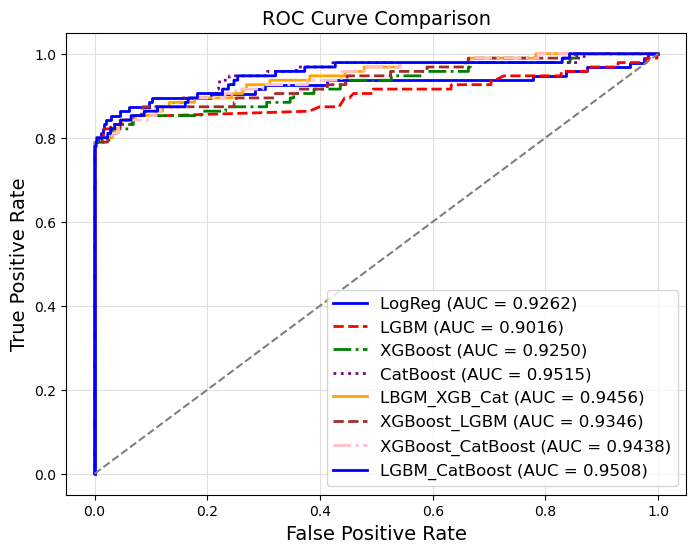

In [46]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Colors for different models
colors = ['blue', 'red', 'green', 'purple', 'orange', 'brown', 'pink']
linestyle = ['-', '--', '-.', ':', '-', '--', '-.']

plt.figure(figsize=(8,6))

for i, (name, value) in enumerate(models.items()):
    
    y_pred = value[0]
    y_prob = value[1]
    
    # Fix shape issues
    if len(y_prob.shape) > 1:
        y_prob = y_prob[:, 1]
    
    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(
        fpr, tpr,
        color=colors[i % len(colors)],
        linestyle=linestyle[i % len(linestyle)],
        label=f'{name} (AUC = {roc_auc:.4f})',
        linewidth=2
    )

# Diagonal line
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')

plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('ROC Curve Comparison', fontsize=14)

plt.legend(loc="lower right", prop={'size': 12})

plt.grid(True, color='#E0E0E0')

plt.show()

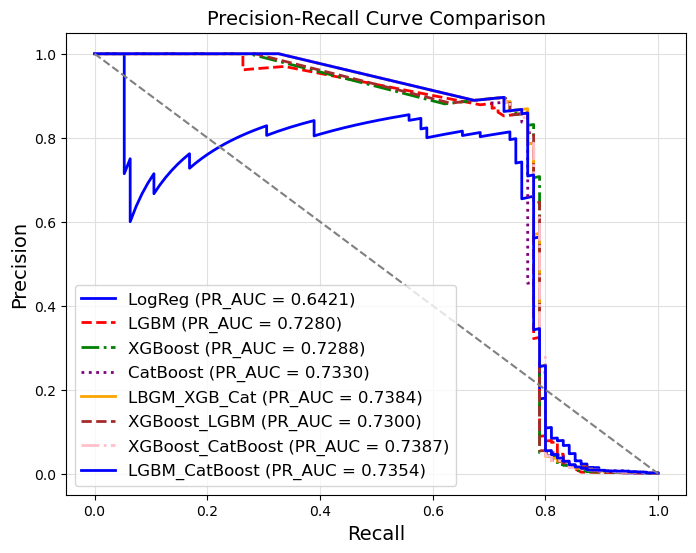

In [47]:
from sklearn.metrics import precision_recall_curve, auc, average_precision_score
import matplotlib.pyplot as plt
import numpy as np

# Colors & styles
colors = ['blue', 'red', 'green', 'purple', 'orange', 'brown', 'pink']
linestyle = ['-', '--', '-.', ':', '-', '--', '-.']

plt.figure(figsize=(8,6))

for i, (name, value) in enumerate(models.items()):
    
    y_pred = value[0]
    y_prob = value[1]
    
    # Fix probability shape
    if len(y_prob.shape) > 1:
        y_prob = y_prob[:, 1]

    # Precision-Recall
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)

    plt.plot(
        recall, precision,
        color=colors[i % len(colors)],
        linestyle=linestyle[i % len(linestyle)],
        label=f'{name} (PR_AUC = {pr_auc:.4f})',
        linewidth=2
    )

# Baseline line
plt.plot([0, 1], [1, 0], linestyle='--', color='gray')

plt.xlabel('Recall', fontsize=14)
plt.ylabel('Precision', fontsize=14)
plt.title('Precision-Recall Curve Comparison', fontsize=14)

plt.legend(loc="lower left", prop={'size': 12})

plt.grid(True, color='#E0E0E0')

plt.show()

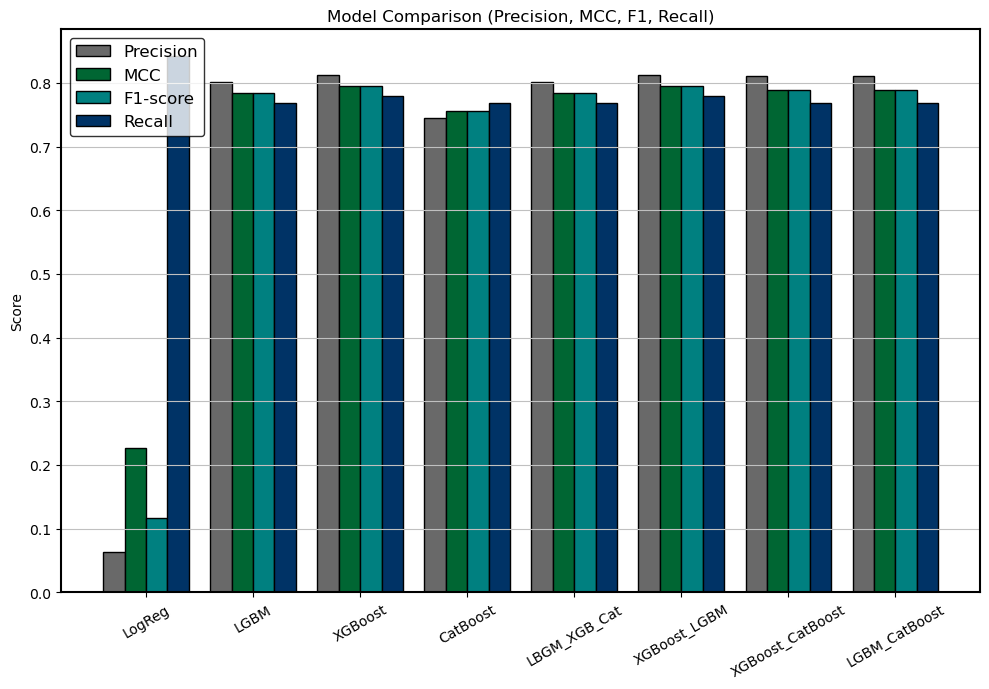

In [48]:
import matplotlib.pyplot as plt
import numpy as np

# Colors (same style as paper)
colors = ['#696969', '#006633', '#008080', '#003366']

# Extract values from results_df
models_names = results_df['Model']

precision = results_df['Precision']
mcc = results_df['MCC']
f1 = results_df['F1']
recall = results_df['Recall']

x = np.arange(len(models_names))  # positions

width = 0.2  # bar width

fig, ax = plt.subplots(figsize=(10,7))

# Plot bars
ax.bar(x - 0.3, precision, width, label='Precision', color=colors[0], edgecolor='black')
ax.bar(x - 0.1, mcc, width, label='MCC', color=colors[1], edgecolor='black')
ax.bar(x + 0.1, f1, width, label='F1-score', color=colors[2], edgecolor='black')
ax.bar(x + 0.3, recall, width, label='Recall', color=colors[3], edgecolor='black')

# X-axis labels
plt.xticks(x, models_names, rotation=30)

# Styling
ax.legend(loc='upper left', prop={'size': 12}, facecolor='white', edgecolor='black')

ax.set_ylabel("Score")
ax.set_title("Model Comparison (Precision, MCC, F1, Recall)")

ax.set_facecolor('white')
ax.yaxis.grid(True, color='#C0C0C0')

for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.show()